In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


=== Train Metrics ===
MAE : 1.4252
MSE : 7.4667
RMSE: 2.7325
MAPE: 0.0378
R2  : 0.9924

=== Test Metrics ===
MAE : 4.1624
MSE : 43.9931
RMSE: 6.6327
MAPE: 0.1299
R2  : 0.9507


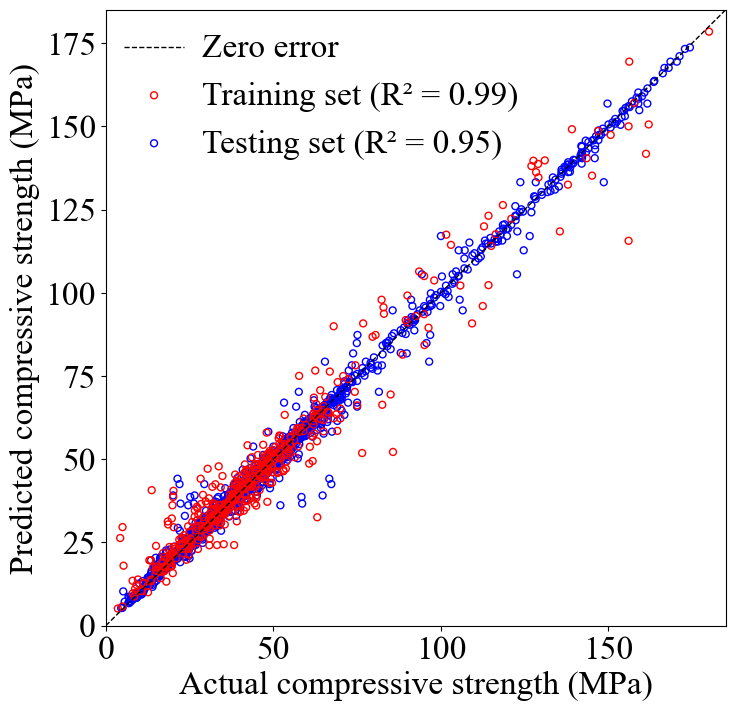

开始训练 CTGAN 生成模型（epochs=30）on full data...


D:\BaiduSyncdisk\python3.12.8\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

D:\BaiduSyncdisk\python3.12.8\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



生成模型训练完成！总耗时: 0 分 19.17 秒
✅ 生成模型训练完成！
CTGAN 生成 150000 条初始合成数据 (特征 + target)...
应用论文通用后处理 (round, 负值置0)...
警告: 列 'Feature_11' 不存在，跳过 Feature_11 相关约束。请检查列名是否与原始数据匹配。
误差过滤 (error < 0.03 * baseline_pred) 后保留 3015 / 150000 条
负 target 过滤 (Com > 0) 后保留 3015 / 3015 条
最终过滤后剩余 3015 条高质量合成数据 (总通过率: 2.01%)
从过滤池中随机选 2307 条作为 syn_data
原数据量: 2307 条

使用提供的 syn_data (大小: 2307 条)

正在处理 ratio = 0.0 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[617]	valid_0's l1: 3.50684	valid_0's l2: 31.0383
Ratio 0.0: RMSE = 5.5712, R² = 0.9668 (合成样本实际添加: 0)

正在处理 ratio = 0.2 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[480]	valid_0's l1: 4.28166	valid_0's l2: 47.7948
Ratio 0.2: RMSE = 6.9134, R² = 0.9328 (合成样本实际添加: 461)

正在处理 ratio = 0.4 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[496]	valid_0's l1: 3.92419	valid_0's l2: 35.1775
Ratio 0.4: RMSE = 5.9311,

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\BaiduSyncdisk\\pytorch\\geopolymer-concrete-ml-pipeline\\Dataset\\Aug\\augmentation.png'

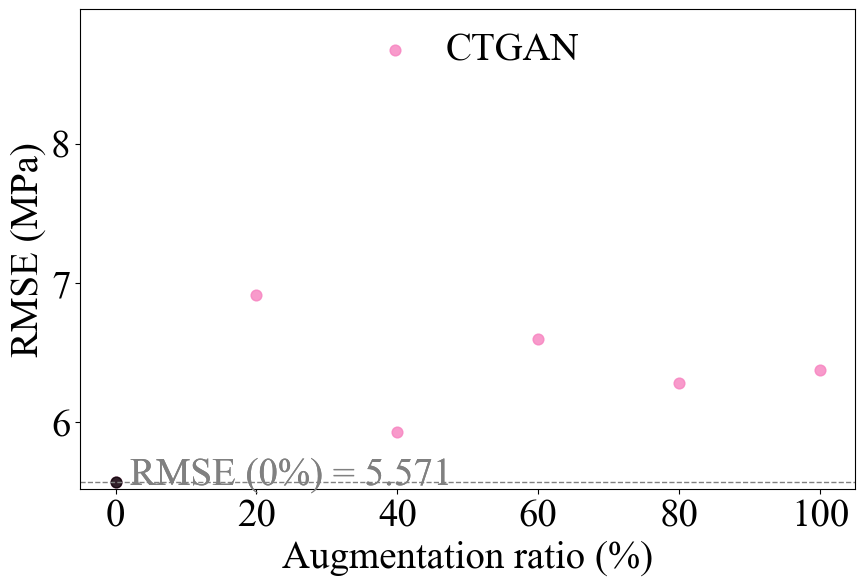

In [23]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.data_process import DataHandler
from src.model_train import *
from src.plotter import DataPlotter
from src.save_utils import build_figure_path

# ===============================
# 1. Load and split data
# ===============================
data_handler = DataHandler("../data/origin_data.xlsx", n_features=16)
data_handler.load_data()

X, y = data_handler.a, data_handler.b

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=172
)

# ===============================
# 2. Train model
# ===============================
result = train_xgboost(x_train, y_train, x_test, y_test)

# ===============================
# 3. Plot (get fig back)
# ===============================
# solve MLP (contain y_train_true) problem
y_train = result.y_train_true if result.y_train_true is not None else y_train
y_test  = result.y_test_true  if result.y_test_true  is not None else y_test

plotter = DataPlotter()
fig, ax = plotter.plot(
    y_train,
    result.y_train_pred,
    y_test,
    result.y_test_pred,
    result.metrics["train"]["r2"],
    result.metrics["test"]["r2"],
)

plt.show()
plt.close(fig)

# ===============================
# 4. 初始化 & 训练生成模型 (Type II，生成特征 + target)
# ===============================
from src.data_augmentation import DataAugmentor

# 获取原始 DataFrame (包含特征和 target)
original_df = data_handler.data_df
target_col = original_df.columns[-1]   # 自动取最后一列（抗压强度）

# 初始化增强器
augmentor = DataAugmentor(baseline_model=result.model)   # result 是你前面训练的基线模型

# 训练生成模型 (CTGAN) —— 现在需要传入完整的 original_df
augmentor.fit_generator(
    full_df=original_df,  # <--- 传入完整的 DataFrame
    method="CTGAN",
    epochs=30,          # 先用300快速测试，成功后再改成2000
    batch_size=500,
    generator_lr=0.0001,
    discriminator_lr=0.0003,
    generator_dim=(512, 1024),
    discriminator_dim=(512, 512),
    verbose=True
)

print("✅ 生成模型训练完成！")


# ===============================
# 5. 运行增强实验（Type II 模式，带误差过滤）
# ===============================
# 定义初始生成样本数
initial_samples = 150000  # 增大初始生成量，确保误差过滤后有足够多的数据

# 定义比率（0%到100%，步长20%）
ratios = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# LightGBM 超参（复用论文 params_2）
lgb_params_for_aug = {
    'objective': 'regression',
    'metric': {'l2', 'l1'},
    'num_leaves': 69,
    'learning_rate': 0.003 * 62,
    'max_depth': 8,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.91,
    'bagging_fraction': 0.6 + 0.01 * 31,
    'bagging_freq': 2,
    'lambda_l1': 0.11,
    'lambda_l2': 0.14,
    'max_bin': 255 - 20,
    'min_split_gain': 0.0,
    'boosting_type': 'gbdt',
    'verbosity': -1,
}

# --- 选项1: 手动生成 syn_data（推荐，可以单独调试生成和过滤） ---
n_original = len(original_df)
syn_data = augmentor.generate_and_predict(
    initial_samples=initial_samples,
    n_original=n_original,
    target_col=target_col
)

# 运行实验（传 syn_data）
aug_results = augmentor.run_augmentation_experiment(
    original_df=original_df,
    ratios=ratios,
    target_col=target_col,
    lgb_params=lgb_params_for_aug,
    syn_data=syn_data  # 传入已生成的 syn_data 池
)

# --- 选项2: 如果不想手动生成，直接运行（内部会调用 generate_and_predict 生成） ---
# aug_results = augmentor.run_augmentation_experiment(
#     original_df=original_df,
#     ratios=ratios,
#     target_col=target_col,
#     lgb_params=lgb_params_for_aug,
#     initial_samples=initial_samples # 内部用这个生成
# )

# 输出结果表
print("\n增强实验结果表:")
print(aug_results)

# 保存结果（可选）
aug_results.to_csv("../results/augmentation_experiment.csv", index=False)



plotter = DataPlotter()
fig, ax = plotter.plot_aug_results_rmse(aug_results, ylabel="RMSE (MPa)", save_path=r"..\Dataset\Aug\augmentation.png")
plt.show()
